### Classification Dataset
We will create dataset using `make_classification` .

Dataset will have :
- 500 samples (`n_samples`) ( number of rows )
- 4 features (`n_features` ) ( number of feature columns )
- 2 classes (`n_classes` ) ( number of classes for classification )

In [1]:
from sklearn.datasets import make_classification

In [2]:
X , y = make_classification(n_samples=500, n_features=4, n_classes=2, random_state=42)

In [3]:
X.shape

(500, 4)

In [4]:
y.shape

(500,)

### Splitting Dataset

Let's split the dataset using `train_test_split` .
- Training Data = 75%
- Testing Data = 25%

In [5]:
from sklearn.model_selection import train_test_split

In [6]:
X_train , X_test , y_train , y_test = train_test_split(X , y , random_state = 42 , test_size=0.25 )

In [7]:
X_train.shape

(375, 4)

In [8]:
y_train.shape

(375,)

### Model Architecture

Let's create a simple Sequential model with **2 fully connected layers** with **ReLU** activation in between.

In [9]:
import torch
import torch.nn as nn
import numpy as np

In [10]:
class SimpleClassifier(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(4, 64),
            nn.ReLU(),
            nn.Linear(64,2)
        )

    def forward(self,x):
        logits = self.model(x)
        return logits

    def predict(self,x_test):
        x_test = torch.asarray(x_test,dtype=torch.float32)
        
        with torch.no_grad():
            y_pred = self.model(x_test)

        y_pred = torch.argmax(y_pred,dim=1) # probabilities into classes

        return y_pred.numpy()

    def train(self, x_train , y_train , epoch = 100):

        # converting ndarray into tensor
        x_train = torch.asarray(x_train,dtype=torch.float32)
        y_train = torch.asarray(y_train,dtype=torch.long)

        # Optimizer and Loss function
        optimizer = torch.optim.Adam(self.model.parameters(),lr=0.01)
        criterion = torch.nn.CrossEntropyLoss()

        # Training loop
        for _ in range(epoch):
            logits = self.model(x_train)
        
            optimizer.zero_grad()
            loss = criterion(logits,y_train)
        
            loss.backward()
            optimizer.step()


### About `SimpleClassifier` class :

we define model in __init__() as `self.model` .

Methods :
- `forward()` : Forward Pass ( returns logits )
- `train()`   : Training ( uses `Adam` optimizer to optimize weights - improves model performance )
- `predict()` : Predicting ( returns 1D numpy array ) 

In [11]:
model = SimpleClassifier()

In [12]:
model.train(X_train,y_train, epoch=1000)

### Prediction , Evaluation

We will predict the values of y using `model.predict` .

We will evaluate based on these metrics :
- `Accuracy`
- `Precision` 
- `Recall` 
- `F1 Score` 
---
#### Accuracy : 
How accurate is the model\
Formula : 
$\text{Precision} =\frac{TP+TN}{TP+TN+FP+FN}$

---

#### Precision : 
How accurately model predicts positive samples\
Formula : 
$\text{Precision} =\frac{TP}{TP+FP}$

---

#### Recall : 
Coverage of positive predictions\
Formula : 
$\text{Precision} =\frac{TP}{TP+FN}$

---
#### F1 Score : 
Harmonic mean of `Precision` and `Recall`\
Formula : 
$\text{Precision} =\frac{2TP}{2TP+FP+FN}$

In [13]:
y_pred = model.predict(X_test)

In [14]:
from sklearn.metrics import accuracy_score , precision_score, recall_score , f1_score, confusion_matrix , classification_report

In [15]:
ac = accuracy_score(y_pred,y_test)
pr = precision_score(y_pred,y_test)
rc = recall_score(y_pred,y_test)
f1 = f1_score(y_pred,y_test)

In [16]:
print(f"Accuracy  : {ac:.4f}")
print(f"Precision : {pr:.4f}")
print(f"Recall    : {rc:.4f}")
print(f"F1 Score  : {rc:.4f}")

Accuracy  : 0.9520
Precision : 0.9714
Recall    : 0.9444
F1 Score  : 0.9444


Or

We can get all of the above metrics using `classification_report`

In [17]:
cr = classification_report(y_pred,y_test)
print(cr)

              precision    recall  f1-score   support

           0       0.93      0.96      0.94        53
           1       0.97      0.94      0.96        72

    accuracy                           0.95       125
   macro avg       0.95      0.95      0.95       125
weighted avg       0.95      0.95      0.95       125



In [18]:
# confusion matrix
cm = confusion_matrix(y_pred,y_test)
print(cm)

[[51  2]
 [ 4 68]]


Let's plot confusion matrix using heatmap

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

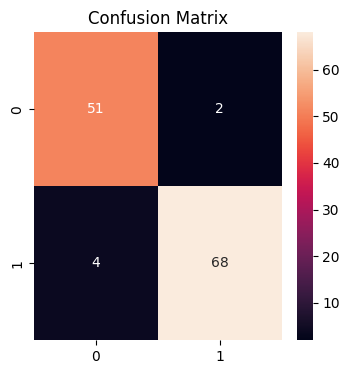

In [20]:
plt.figure(figsize=(4, 4))
sns.heatmap(cm,annot=True)
plt.title('Confusion Matrix')
plt.grid(False)
plt.show()